In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/loan_data.csv")

# Show first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null   

In [4]:
# Fill categorical missing values with mode

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Fill numerical missing values with median

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

In [5]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Columns to encode
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

# Apply encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Show first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [7]:
# Features (input data)
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

# Target (output)
y = df['Loan_Status']

# Display shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (614, 11)
y Shape: (614,)


In [8]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (491, 11)
X_test Shape: (123, 11)
y_train Shape: (491,)
y_test Shape: (123,)


In [9]:
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\KIIT\Desktop\Explainable-Loan-Approval-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [12]:
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=2000)

# Train using scaled data
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully after scaling!")

Logistic Regression model trained successfully after scaling!


In [13]:
# Make predictions
y_pred = lr_model.predict(X_test_scaled)

# Show first 10 predictions
print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [14]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [15]:
from sklearn.metrics import classification_report

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



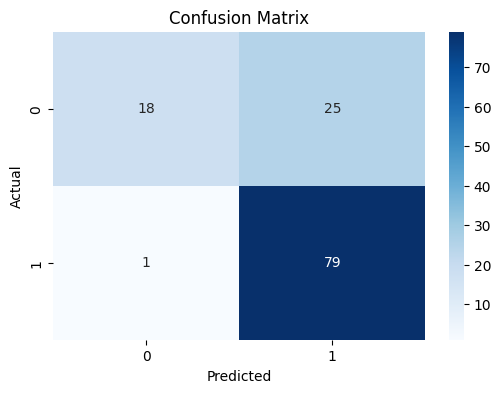

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
# Predictions
rf_predictions = rf_model.predict(X_test)

# Show first 10 predictions
print(rf_predictions[:10])

[1 1 1 0 1 1 1 1 1 1]


In [19]:
from sklearn.metrics import accuracy_score

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7560975609756098


In [20]:
# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display results
print(feature_importance)

              Feature  Importance
9      Credit_History    0.262914
5     ApplicantIncome    0.202666
7          LoanAmount    0.185022
6   CoapplicantIncome    0.113861
8    Loan_Amount_Term    0.051443
10      Property_Area    0.049602
2          Dependents    0.048141
1             Married    0.023648
3           Education    0.021271
0              Gender    0.020718
4       Self_Employed    0.020713


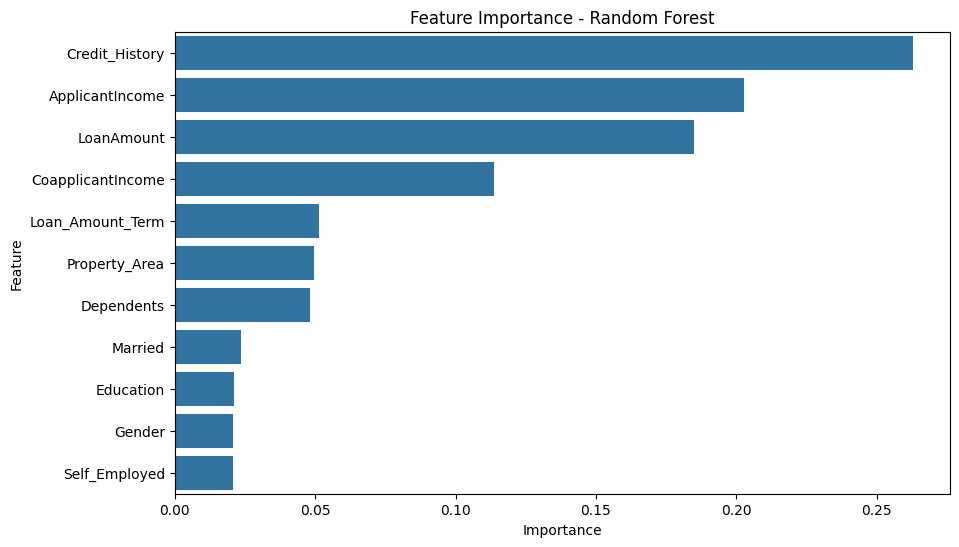

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10,6))

# Plot feature importance
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

# Title
plt.title("Feature Importance - Random Forest")

# Show graph
plt.show()

In [22]:
import shap

print("SHAP imported successfully!")

SHAP imported successfully!


In [23]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


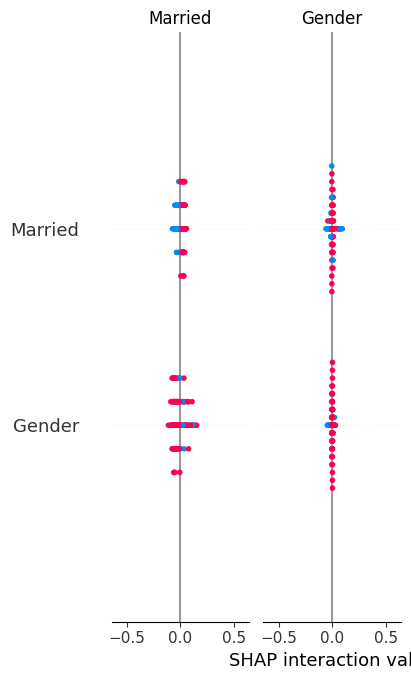

In [24]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test)

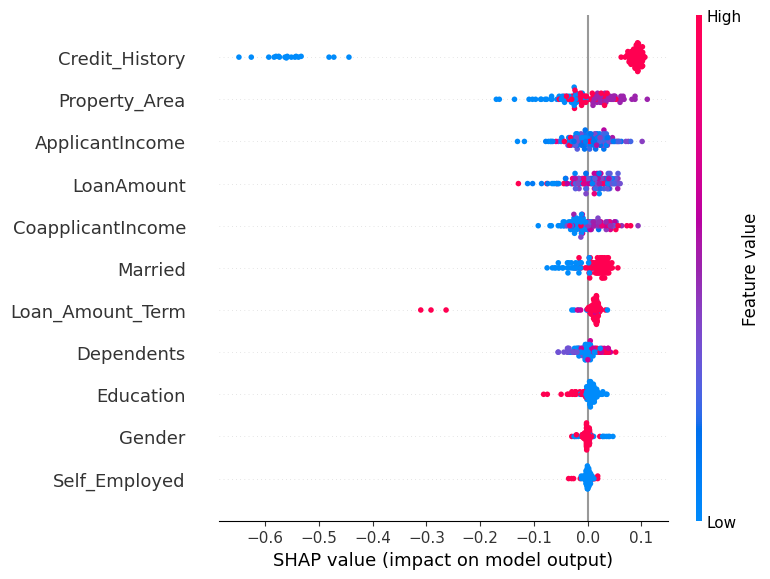

In [25]:
# Better SHAP summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)

In [26]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [27]:
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [28]:
# Predictions
xgb_predictions = xgb_model.predict(X_test)

# Show first 10 predictions
print(xgb_predictions[:10])

[1 1 1 1 1 1 1 1 1 1]


In [29]:
from sklearn.metrics import accuracy_score

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7560975609756098


In [30]:
# Model comparison
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.788618
1        Random Forest  0.756098
2              XGBoost  0.756098


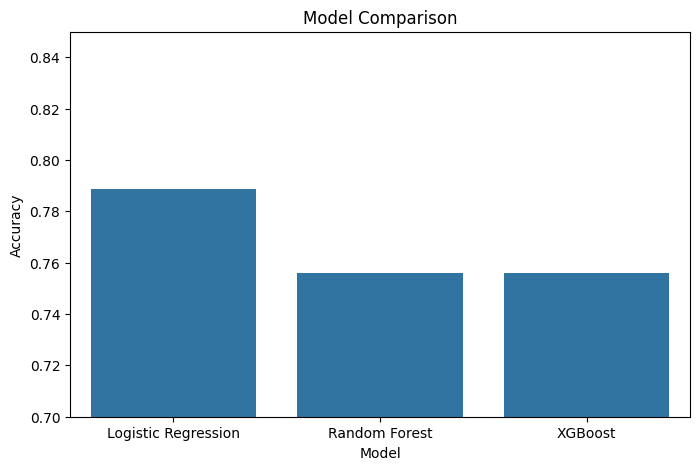

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_comparison
)

plt.title("Model Comparison")
plt.ylim(0.7, 0.85)

plt.show()

In [32]:
import joblib

# Save Logistic Regression model
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
